In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import nltk

In [4]:
df=pd.read_csv(r'D:\ProjectExhibition1\ProjectExb\Corona_Wave2.csv')

In [5]:

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean text
def clean_text(text):
    try:
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        # Remove special characters and numbers
        text = re.sub(r'[^A-Za-z\s]', '', text)
        # Lowercase the text
        text = text.lower()
        # Tokenize the text
        tokens = word_tokenize(text)
        # Remove stop words
        tokens = [word for word in tokens if word not in stopwords.words('english')]
        # Lemmatize the tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        # Join the tokens back into a single string
        cleaned_text = ' '.join(tokens)
        return cleaned_text
    except Exception as e:
        print(f"Error processing text: {text}\n{e}")
        return ''


# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)

# Display the cleaned DataFrame
print(df[['text', 'cleaned_text']].head())


                                                text  \
0  Quite an uncommon #Schanzer #Matchday tomorrow...   
1  మళ్లీ లాక్‌డౌన్? ఆపాలంటే ఇదే మార్గం: Prof K Na...   
2  Lockdown: Testing, ventilators and vaccines .....   
3  i hate when people say things like “corona was...   
4  @im_viratian_ @RCBTweets Corona , second wave ...   

                                        cleaned_text  
0  quite uncommon tomorrow bavarian cup totopokal...  
1  prof k nageshwar analysis corona effect indian...  
2  lockdown testing ventilator vaccine india come...  
3  hate people say thing like corona blessing dis...  
4                           corona second wave whats  


In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer
# from tqdm.notebook import tqdm
from tqdm.auto import tqdm

sia=SentimentIntensityAnalyzer()

In [7]:
res={}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['cleaned_text']
    myid = row['id']
    res[myid]= sia.polarity_scores(text)
    

  0%|          | 0/14000 [00:00<?, ?it/s]

In [8]:
vaders=pd.DataFrame(res).T
vaders=vaders.reset_index().rename(columns={'index':'id'})
vaders=vaders.merge(df,how='left')
vaders.head()

,id,neg,neu,pos,compound,text,cleaned_text
0,1,0.167,0.833,0.000,-0.2023,Quite an uncommon #Schanzer #Matchday tomorrow...,quite uncommon tomorrow bavarian cup totopokal...
1,2,0.000,1.000,0.000,0.0000,మళ్లీ లాక్‌డౌన్? ఆపాలంటే ఇదే మార్గం: Prof K Na...,prof k nageshwar analysis corona effect indian...
2,3,0.000,1.000,0.000,0.0000,"Lockdown: Testing, ventilators and vaccines .....",lockdown testing ventilator vaccine india come...
3,4,0.273,0.335,0.392,0.3612,i hate when people say things like “corona was...,hate people say thing like corona blessing dis...
4,5,0.000,1.000,0.000,0.0000,"@im_viratian_ @RCBTweets Corona , second wave ...",corona second wave whats


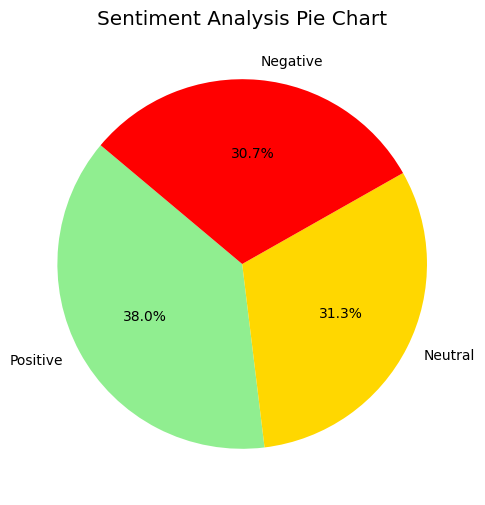

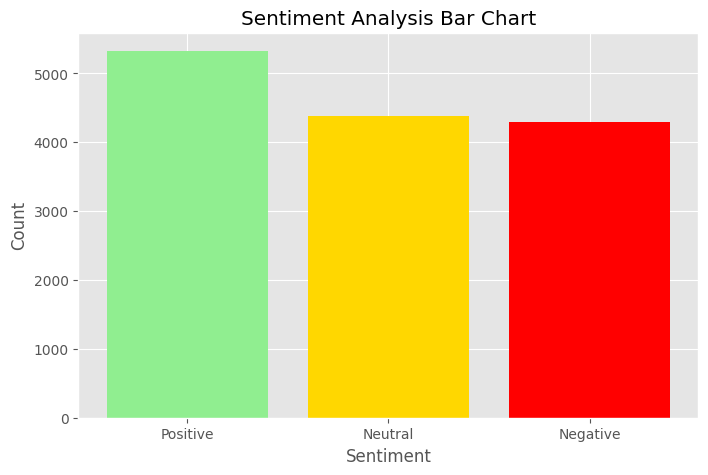

In [9]:
conditions = {
    'Positive': (vaders['compound'] > 0),
    'Neutral': (vaders['compound'] == 0),
    'Negative': (vaders['compound'] < 0)
}

sentiment_counts = {key: sum(value) for key, value in conditions.items()}

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values(),
    labels=sentiment_counts.keys(),
    autopct='%1.1f%%',
    colors=['lightgreen', 'gold', 'red'],
    startangle=140
)
plt.title('Sentiment Analysis Pie Chart')
plt.show()

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.keys(), sentiment_counts.values(), color=['lightgreen', 'gold', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis Bar Chart')
plt.show()